In [1]:
import gymnasium as gym
import ale_py

from stable_baselines3 import PPO
from stable_baselines3.common.atari_wrappers import AtariWrapper

In [2]:
gym.register_envs(ale_py)

In [19]:
from stable_baselines3.common.monitor import Monitor

env = gym.make("ALE/KingKong-v5")
env = AtariWrapper(env)
env = Monitor(env, "./logs")

In [20]:
model = PPO(
    "CnnPolicy",
    env,
    verbose=1,
    n_steps=128,
    batch_size=256,
)

Using cpu device
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


C:\Users\ddoris\AppData\Local\anaconda3\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


In [25]:
from stable_baselines3.common.callbacks import BaseCallback

class RewardLogger(BaseCallback):
    def __init__(self, check_freq=1000):
        super().__init__()
        self.check_freq = check_freq

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            print(f"Step: {self.num_timesteps}")
        return True

In [26]:
callback = RewardLogger()

model.learn(total_timesteps=100000, callback=callback)

----------------------------
| time/              |     |
|    fps             | 271 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 128 |
----------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 132        |
|    ep_rew_mean          | 1          |
| time/                   |            |
|    fps                  | 212        |
|    iterations           | 2          |
|    time_elapsed         | 1          |
|    total_timesteps      | 256        |
| train/                  |            |
|    approx_kl            | 0.01016769 |
|    clip_fraction        | 0.281      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.18      |
|    explained_variance   | -0.0239    |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0148    |
|    n_updates            | 800        |
|    policy_gradient_loss | -0.0158    |
|    value_loss   

In [27]:
from stable_baselines3.common.evaluation import evaluate_policy

mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5)

print("Mean reward:", mean_reward)
print("Std reward:", std_reward)

Mean reward: 2.2
Std reward: 2.9933259094191533


In [28]:
model.save("kingkong_ppo3")

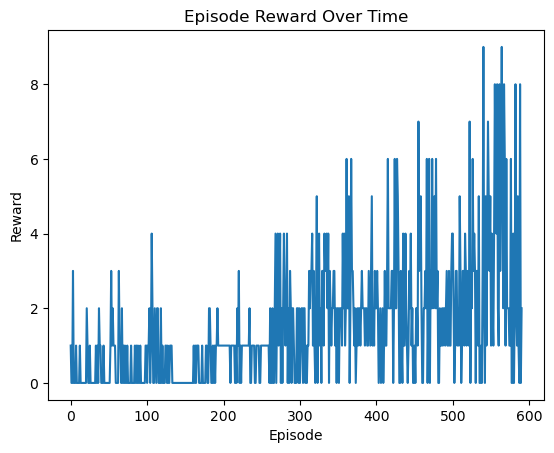

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("./logs.monitor.csv", skiprows=1)

# Plot rewards
plt.figure()
plt.plot(df["r"])
plt.title("Episode Reward Over Time")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

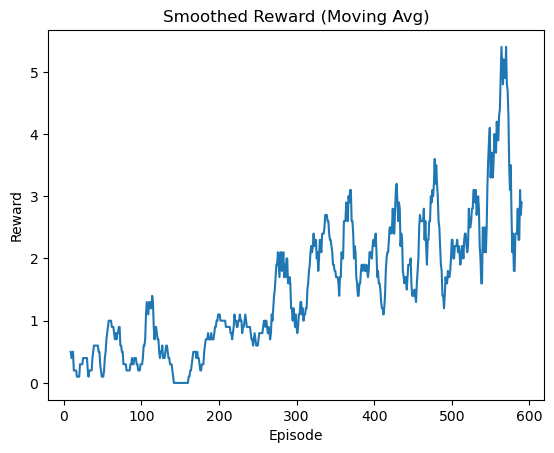

In [30]:
df["reward_smooth"] = df["r"].rolling(window=10).mean()

plt.figure()
plt.plot(df["reward_smooth"])
plt.title("Smoothed Reward (Moving Avg)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

In [31]:
env = gym.make("ALE/KingKong-v5", render_mode="human")
env = AtariWrapper(env)

from stable_baselines3 import PPO
model = PPO.load("kingkong_ppo1.zip")

obs, _ = env.reset()

while True:
    action, _ = model.predict(obs)
    obs, _, terminated, truncated, _ = env.step(action)

    if terminated or truncated:
        obs, _ = env.reset()

KeyboardInterrupt: 